# LTV Forecast Model (or CLV, Customer Life-Time Value)

Medium blog: [Customer Lifetime Value Prediction with PyMC-Marketing](https://medium.com/data-science/pymc-marketing-the-key-to-advanced-clv-customer-lifetime-value-forecasting-bc0730973c0a)

The definition of CLV is the **total net revenue a company can expect from a single customer throughout their relationship**. Some of you might be more familiar with the term ‘LTV’ (Lifetime Value). Here CLV and LTV are interchangeable.

* [code](https://github.com/takechanman1228/Effective-CLV-Modeling/blob/main/PyMC_Marketing_CLV_demo.ipynb)
* **PyMC-Marketing** is a Python-based library.

## CLV Modeling

* **Historical Approach** (traditional formula):
    * CLV = (avg order value) * (purchase frequency) * (customer lifespan)
* **Predictive Approach**:
    * Probabilistic Model: Buy-till-you-die (BTYD) model
    * Machine Learning Model: Random forest, GBM, DNN

In [1]:
import pandas as pd
import os

In [2]:
# Convert from Excel to CSV
data_raw = pd.read_excel("Online Retail.xlsx")
data_raw.shape

(541909, 8)

In [3]:
data_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Handling Return Orders
# Extracting rows where InvoiceNo starts with "C"
cancelled_orders = data_raw[data_raw['InvoiceNo'].astype(str).str.startswith("C")]

# Create a temporary DataFrame with the columns we want to match on, and also negate the 'Quantity' column
cancelled_orders['Quantity'] = -cancelled_orders['Quantity']

# Merge the original DataFrame with the temporary DataFrame on the columns we want to match
merged_data = pd.merge(data_raw, cancelled_orders[['CustomerID', 'StockCode', 'Quantity', 'UnitPrice']], 
                       on=['CustomerID', 'StockCode', 'Quantity', 'UnitPrice'], 
                       how='left', indicator=True)

# Filter out rows where the merge found a match, and also filter out the original return orders
data_raw = merged_data[(merged_data['_merge'] == 'left_only') & (~merged_data['InvoiceNo'].astype(str).str.startswith("C"))]

# Drop the indicator column
data_raw = data_raw.drop(columns=['_merge'])

# Selecting relevant features and calculating total sales
features = ['CustomerID', 'InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice', 'Country']
data = data_raw[features]
data['TotalSales'] = data['Quantity'].multiply(data['UnitPrice'])

# Removing transactions with missing customer IDs as they don't contribute to individual customer behavior
data = data[data['CustomerID'].notna()]
data['CustomerID'] = data['CustomerID'].astype(int).astype(str)
data.head()

,CustomerID,InvoiceNo,InvoiceDate,Quantity,UnitPrice,Country,TotalSales
0,17850,536365,2010-12-01 08:26:00,6,2.55,United Kingdom,15.30
1,17850,536365,2010-12-01 08:26:00,6,3.39,United Kingdom,20.34
2,17850,536365,2010-12-01 08:26:00,8,2.75,United Kingdom,22.00
3,17850,536365,2010-12-01 08:26:00,6,3.39,United Kingdom,20.34
4,17850,536365,2010-12-01 08:26:00,6,3.39,United Kingdom,20.34


## Data in RFM-T format 

RFM-T means **Recency**, **Frequency**, **Monetary**, and **Tenure** of each customer.

In [4]:
from pymc_marketing import clv

data_summary_rfm = clv.utils.rfm_summary(data, 'CustomerID', 'InvoiceDate', 'TotalSales')
data_summary_rfm = data_summary_rfm.rename(columns={'CustomerID': 'customer_id'})
data_summary_rfm.index = data_summary_rfm['customer_id']
data_summary_rfm.head()

/Users/hsianghung/anaconda3/envs/casual_ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,customer_id,frequency,recency,T,monetary_value
customer_id,,,,,
12347,12347,6.0,365.0,367.0,599.701667
12348,12348,3.0,283.0,358.0,301.480000
12349,12349,0.0,0.0,18.0,0.000000
12350,12350,0.0,0.0,310.0,0.000000
12352,12352,5.0,260.0,296.0,221.756000


In [6]:
data_summary_rfm = data_summary_rfm[data_summary_rfm['monetary_value'] > 0]

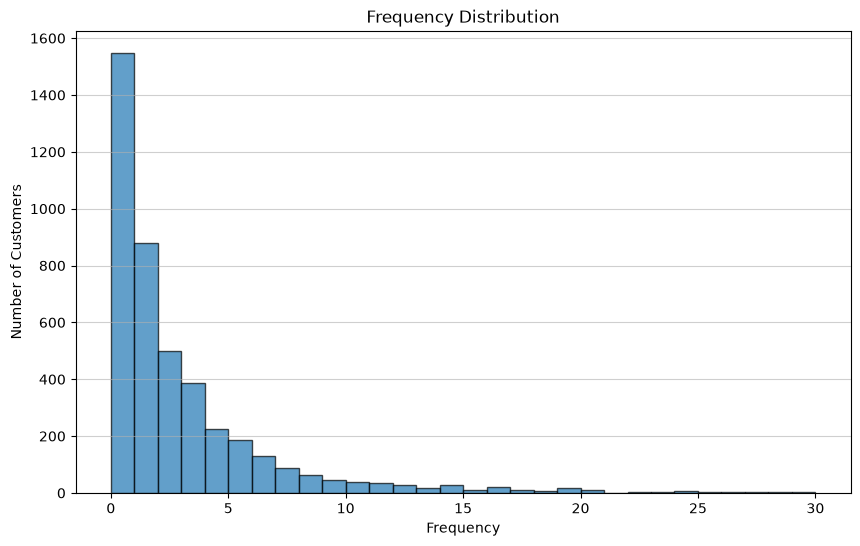

Percentage of customers who purchased only once: 20.34%


In [7]:
import matplotlib.pyplot as plt

# Plotting the frequency distribution of customers
plt.figure(figsize=(10, 6))
plt.hist(data_summary_rfm['frequency'], bins=30, range=[0, 30], edgecolor='k', alpha=0.7)
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.6)
plt.show()

one_time = round(sum(data_summary_rfm['frequency'] == 1) / float(len(data_summary_rfm)) * 100, 2)
print(f"Percentage of customers who purchased only once: {one_time}%")

## Buy-Till-You-Die (BTYD) Model

This approach comprises two sub-models:

1. **BG-NBD model**:This predicts the likelihood of a customer being active and their transaction frequency.
2. **Gamma-Gamma model**: This estimates the average order value.

By combining the results from these sub-models, we can effectively forecast the Customer Lifetime Value (CLV).


![](./images/BTYD_model_summary.png)


### BG/NBD Model

In [12]:
bgm = clv.BetaGeoModel(
    data = data_summary_rfm,
)
bgm.build_model()

bgm.fit()
bgm.fit_summary()
bgm

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi_dropout, kappa_dropout, r]


/Users/hsianghung/anaconda3/envs/casual_ml/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


BG/NBD
            alpha ~ Weibull(2, 10)
      phi_dropout ~ Uniform(0, 1)
    kappa_dropout ~ Pareto(1, 1)
                r ~ Weibull(2, 1)
                a ~ Deterministic(f(kappa_dropout, phi_dropout))
                b ~ Deterministic(f(kappa_dropout, phi_dropout))
recency_frequency ~ BetaGeoNBD(a, b, r, alpha, <constant>)

<Axes: title={'center': 'Probability Customer is Alive,\nby Frequency and Recency of a Customer'}, xlabel="Customer's Historical Frequency", ylabel="Customer's Recency">

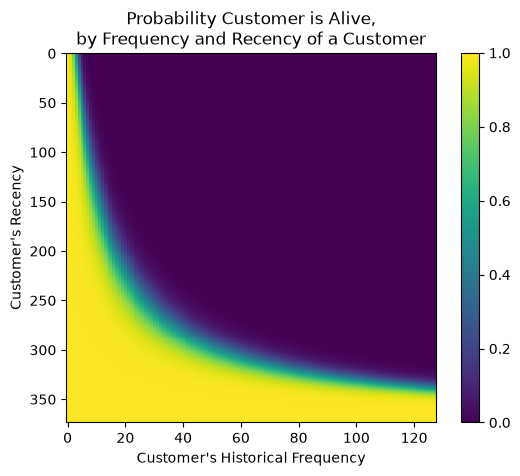

In [10]:
clv.plot_probability_alive_matrix(bgm)

### Fine-tune BG/NBD Model

In [13]:
model_config = {
    'a_prior': {'dist': 'HalfNormal',
                'kwargs': {'sigma': 100}},
    'b_prior': {'dist': 'HalfNormal',
                'kwargs': {'sigma': 100}},
    'alpha_prior': {'dist': 'HalfNormal',
                'kwargs': {'sigma': 100}},
    'r_prior': {'dist': 'HalfNormal',
                'kwargs': {'sigma': 100}},
}

# Rebuilding the model with updated prior configurations.
bgm = clv.BetaGeoModel(
    data = data_summary_rfm,
    model_config = model_config,
)
bgm.build_model()
bgm

BG/NBD
            alpha ~ HalfNormal(0, 100)
                a ~ HalfNormal(0, 100)
                b ~ HalfNormal(0, 100)
                r ~ HalfNormal(0, 100)
recency_frequency ~ BetaGeoNBD(a, b, r, alpha, <constant>)

In [14]:
bgm.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, a, b, r]


/Users/hsianghung/anaconda3/envs/casual_ml/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> fit_data

In [17]:
num_purchases = bgm.expected_purchases(
    customer_id=data_summary_rfm["customer_id"],
    t=365,
    future_t=10,
    frequency=data_summary_rfm["frequency"],
    recency=data_summary_rfm["recency"],
    T=data_summary_rfm["T"]
)

sdata = data_summary_rfm.copy()
sdata["expected_purchases"] = num_purchases.mean(("chain", "draw")).values
sdata.sort_values(by="expected_purchases").tail(4)

TypeError: BetaGeoModel.expected_purchases() got an unexpected keyword argument 'customer_id'

### Gamma-Gamma model

In [18]:
nonzero_data = data_summary_rfm.query("frequency>0")
dataset = pd.DataFrame({
    'customer_id': nonzero_data.customer_id,
    'mean_transaction_value': nonzero_data["monetary_value"],
    'frequency': nonzero_data["frequency"],
})
gg = clv.GammaGammaModel(
    data = dataset
)
gg.build_model()
gg.fit();

expected_spend = gg.expected_customer_spend(
    customer_id=data_summary_rfm["customer_id"],
    mean_transaction_value=data_summary_rfm["monetary_value"],
    frequency=data_summary_rfm["frequency"],
)

ValueError: The following required columns are missing from the input data: ['monetary_value']